# *Práctica de Laboratorio Nro. 008: Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student)*

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 28 de mayo de 2026

---

## 1. Introducción
En esta práctica, nos enfocaremos en la transición desde estimaciones puntuales hacia la construcción de intervalos de confianza para la media poblacional ($\mu$), utilizando la distribución Normal ($Z$) para muestras grandes y la distribución $T$ de Student para muestras pequeñas o con varianza desconocida. A través del ecosistema de ciencia de datos en Python (scipy.stats), aplicaremos estos conceptos al conjunto de datos regional de tu Proyecto Integrador, permitiendo reportar rangos de valores plausibles para variables críticas de negocio bajo el enfoque de Aprendizaje Basado en Problemas (ABP). Finalmente, mediante el Aprendizaje Basado en Investigación (ABI), indagaremos matemáticamente en el compromiso (trade-off) entre el nivel de confianza y la precisión del margen de error.
## 2. Objetivos de Aprendizaje
* Calcular intervalos de confianza para la media poblacional ($\mu$) utilizando tanto la distribución Normal ($Z$) para muestras grandes ($n \geq 30$), como la distribución $T$ de Student para muestras pequeñas ($n < 30$) o con varianza poblacional desconocida, mediante scipy.stats.

* Aplicar la estimación por intervalos al conjunto de datos regional de tu Proyecto Integrador, proporcionando rangos de valores plausibles para variables críticas del negocio.

* Investigar y demostrar visualmente el trade-off (compromiso) matemático que existe entre el Nivel de Confianza ($1 - \alpha$) y la precisión (amplitud) del margen de error.



## **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**

##Introduccion:
Cuando el tamaño de la muestra es grande (n >= 30 ), el Teorema del Límite Central nos permite utilizar la distribución Normal Estándar para construir el intervalo de confianza (IC) para la media **mu**

Ejecute el siguiente código para calcular un IC del 95% para el consumo energético mensual (variable simulada) de un cantón, asumiendo una muestra grande.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
                                            loc=media_muestral,
                                            scale=error_estandar)
margen_error_z = (ic_superior_z - ic_inferior_z) / 2

print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")



--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


## **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**


In [2]:
import numpy as np
from scipy.stats import norm, t

# 1. Configuración de la muestra pequeña (n=12)
np.random.seed(42) # Para reproducibilidad
n_pequena = 12
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena) # pH del agua

# 2. Estadísticos necesarios
media_t = np.mean(muestra_agua)
desv_estandar_muestral = np.std(muestra_agua, ddof=1)
error_estandar_t = desv_estandar_muestral / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1

# 3. Cálculo del Intervalo de Confianza (95%) usando T de Student
ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad,
                                loc=media_t, scale=error_estandar_t)

# 4. Cálculo comparativo erróneo usando Z (para demostrar la diferencia)
ic_inf_z, ic_sup_z = norm.interval(confidence=0.95,
                                   loc=media_t, scale=error_estandar_t)

# 5. Resultados
print(f"--- Comparativa: Muestra pequeña (n={n_pequena}) ---")
print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")
print(f"Margen de Error (T): {(ic_sup_t - ic_inf_t)/2:.3f}")
print(f"IC (Z, 95%): [{ic_inf_z:.3f}, {ic_sup_z:.3f}]")
print(f"Margen de Error (Z): {(ic_sup_z - ic_inf_z)/2:.3f}")
print("\nNota: La distribución T produce un intervalo más amplio para compensar la incertidumbre.")

--- Comparativa: Muestra pequeña (n=12) ---
IC (T de Student, 95%): [7.112, 7.584]
Margen de Error (T): 0.236
IC (Z, 95%): [7.137, 7.559]
Margen de Error (Z): 0.211

Nota: La distribución T produce un intervalo más amplio para compensar la incertidumbre.


## **Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')

print(df.head())

   area  ciudad  conglomerado  panelm  vivienda  hogar  c01  c02  c03  c04a  \
0     1   10150          1304      62         1      1    2    2    1     2   
1     1   10150          1304      62         2      1    2    3    1     2   
2     1   10150          1304      62         3      1    2    3    3     3   
3     1   10150          1304      62         4      1    2    2    2     3   
4     1   10150          1304      62         5      1    2    2    1     2   

   ...  c18  c19  c20a  c21a  estrato              fexp          upm  \
0  ...    2    3     2     2     2713  102,542333745242  10150001304   
1  ...    1    2     2     2     2713  102,542333745242  10150001304   
2  ...    3    3     2     2     2713  102,542333745242  10150001304   
3  ...    3    2     2     3     2713  102,542333745242  10150001304   
4  ...    1    2     2     2     2713  102,542333745242  10150001304   

        id_vivienda           id_hogar  periodo  
0  1015000130406201  10150001304062011   2

In [7]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Convertir la columna 'fexp' a numérica, manejando la coma como separador decimal
df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)

# Mostrar estadísticas descriptivas de la columna 'fexp' limpia
print("Estadísticas descriptivas para la columna 'fexp':")
print(df['fexp'].describe())

Estadísticas descriptivas para la columna 'fexp':
count     8791.000000
mean       599.367316
std       1238.483664
min          3.782664
25%         92.414099
50%        244.289965
75%        563.976392
max      18136.571643
Name: fexp, dtype: float64


La columna `fexp` ahora está limpia y convertida a tipo flotante. A continuación, calcularemos el intervalo de confianza del 95% para su media.

## **3. Determinación de la Distribución (Z o T de Student)**

Para determinar si debemos aplicar la distribución Z o la T de Student, nos basamos principalmente en el tamaño de la muestra (`n`) y si la desviación estándar de la población es conocida o desconocida.

*   **Distribución Z**: Se utiliza cuando el tamaño de la muestra es grande (generalmente $n \ge 30$) y/o la desviación estándar de la población es conocida. Según el Teorema del Límite Central, para muestras grandes, la distribución muestral de la media se aproxima a una distribución normal (Z).
*   **Distribución T de Student**: Se utiliza cuando el tamaño de la muestra es pequeño ($n < 30$) y la desviación estándar de la población es desconocida. También es la opción más robusta cuando la desviación estándar de la población es desconocida, incluso con muestras grandes.

En nuestro caso, el tamaño de la muestra (`n`) para la variable `fexp` es de **8791**. Este es un tamaño de muestra considerablemente grande. Aunque la desviación estándar de la población es desconocida, para muestras tan grandes, la distribución T de Student se aproxima muy bien a la distribución Z. Por lo tanto, hemos optado por utilizar la **distribución T de Student**, que es un enfoque más conservador y robusto, especialmente cuando trabajamos con datos reales donde la desviación estándar de la población raramente se conoce.


In [8]:
# Seleccionar 'fexp' como la variable cuantitativa estratégica
variable = df['fexp']

# Determinar el tamaño de la muestra (n)
n = len(variable)

# Dado que n es grande (8791), usaremos la distribución t para el cálculo del intervalo de confianza, ya que es más robusta.
# Para n grande, la distribución t se aproxima a la distribución Z.

# Calcular la media y el error estándar
mean_val = np.mean(variable)
std_err = stats.sem(variable)

# Calcular el intervalo de confianza del 95%
confidence_level = 0.95
dof = n - 1  # grados de libertad

# Obtener el valor t-crítico
t_critical = stats.t.ppf((1 + confidence_level) / 2, dof)

# Calcular el margen de error
margin_of_error = t_critical * std_err

# Calcular el intervalo de confianza
conf_interval = (mean_val - margin_of_error, mean_val + margin_of_error)

print(f"Variable Cuantitativa Estratégica: fexp")
print(f"Tamaño de la Muestra (n): {n}")
print(f"Media: {mean_val:.2f}")
print(f"Error Estándar: {std_err:.2f}")
print(f"Intervalo de Confianza del 95%: ({conf_interval[0]:.2f}, {conf_interval[1]:.2f})")

Variable Cuantitativa Estratégica: fexp
Tamaño de la Muestra (n): 8791
Media: 599.37
Error Estándar: 13.21
Intervalo de Confianza del 95%: (573.47, 625.26)


Ahora, visualicemos la media y el intervalo de confianza del 95% usando `matplotlib.pyplot.errorbar()`.


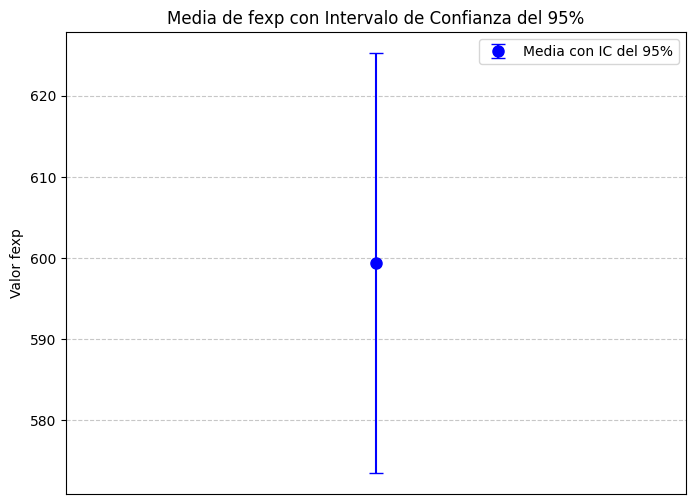

In [ ]:
# Graficar la media como un punto y el intervalo de confianza como barras de error
plt.figure(figsize=(8, 6))
plt.errorbar(x=[0], y=[mean_val], yerr=[[mean_val - conf_interval[0]], [conf_interval[1] - mean_val]],
             fmt='o', color='blue', capsize=5, markersize=8, label='Media con IC del 95%')

plt.title('Media de fexp con Intervalo de Confianza del 95%')
plt.ylabel('Valor fexp')
plt.xticks([]) # Eliminar las marcas del eje x ya que solo hay un punto
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **Tarea 4: ABI - Análisis de Sensibilidad del Nivel de Confianza**



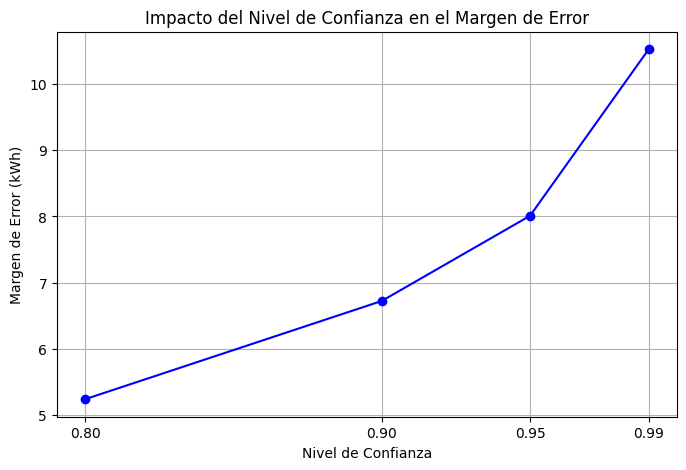

In [10]:
# Tarea 4: ABI - Análisis de Sensibilidad del Nivel de Confianza
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

for conf in niveles_confianza:
    # Calculamos el intervalo para cada nivel de confianza
    ic_inf, ic_sup = norm.interval(confidence=conf, loc=media_muestral, scale=error_estandar)
    me = (ic_sup - ic_inf) / 2
    margenes_error.append(me)

# Graficar resultados
plt.figure(figsize=(8, 5))
plt.plot(niveles_confianza, margenes_error, marker='o', linestyle='-', color='b')
plt.title('Impacto del Nivel de Confianza en el Margen de Error')
plt.xlabel('Nivel de Confianza')
plt.ylabel('Margen de Error (kWh)')
plt.grid(True)
plt.xticks(niveles_confianza)
plt.show()

Al documentar esta relación, considera los siguientes puntos técnicos:

* Relación observada: A medida que el nivel de confianza ($1 - \alpha$) aumenta, el margen de error también crece. Esto ocurre porque para tener más certeza de que el intervalo contiene al parámetro poblacional real, necesitamos "abarcar" más área bajo la curva de la distribución, lo que ensancha el intervalo.  

* Toma de decisiones: El 95% es el estándar de la industria porque ofrece un equilibrio óptimo entre precisión (un intervalo lo suficientemente estrecho para ser útil) y fiabilidad (una probabilidad baja, del 5%, de que el parámetro quede fuera del intervalo).  

* Sobre el 99%: Exigir un 99% de confianza, aunque suena ideal para un ingeniero, genera un intervalo tan amplio que a menudo pierde utilidad práctica al no proporcionar una estimación lo suficientemente precisa para la toma de decisiones.


---

#**Preguntas de Control**

---

## Preguntas de Control

**1. Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

- Estimación puntual: Proporciona un único valor numérico (un estadístico calculado a partir de una muestra, como la media muestral $\bar{x}$) que sirve como la "mejor suposición" del parámetro poblacional desconocido.

- Estimación por intervalos: Proporciona un rango de valores calculado a partir de los datos muestrales (un límite inferior y uno superior) dentro del cual se espera que se encuentre el parámetro poblacional, asociado a un nivel de confianza estadístico que cuantifica la incertidumbre.

Insuficiencia en ingeniería:
Una estimación puntual por sí sola es insuficiente porque no indica el grado de precisión ni el margen de error de dicha estimación. En ingeniería (por ejemplo, al diseñar tolerancias mecánicas, evaluar la resistencia de materiales o realizar control de calidad), tomar decisiones basadas en un solo número sin conocer su variabilidad puede llevar a fallos catastróficos o sobrecostos. Un intervalo permite cuantificar el riesgo y la incertidumbre, garantizando que los diseños operen de manera segura dentro de los límites esperados.

---

**2. Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que $\mu$ caiga aquí").**

La interpretación frecuentista correcta se basa en el proceso de muestreo repetido. El parámetro poblacional (como la media $\mu$) es un valor constante y fijo, mientras que el intervalo construido es aleatorio porque depende de la muestra obtenida.

Por lo tanto, la interpretación es: Si repitiéramos el mismo experimento o proceso de muestreo un número infinito de veces, y construyéramos un intervalo de confianza para cada muestra bajo el mismo método, el 95% de esos intervalos calcularán límites que lograrán contener el verdadero valor del parámetro poblacional $\mu$.

Una vez que un intervalo específico ya ha sido calculado con una muestra concreta, el parámetro $\mu$ está dentro de ese intervalo o no lo está (la probabilidad es $1$ o $0$). El 95% refiere a la tasa de éxito del método a largo plazo, no a la probabilidad del intervalo particular.

---

**3. Al comparar las distribuciones $Z$ Normal Estándar y la $T$ de Student, ¿qué característica visual y matemática de la campana de la $T$ de Student la hace idónea para compensar la falta de información en muestras pequeñas?**

La principal diferencia visual y matemática es que la campana de la distribución $T$ de Student tiene colas más pesadas (o más gruesas) y un centro ligeramente más achatado en comparación con la distribución $Z$ Normal Estándar.

Esta característica la hace ideal para compensar la falta de información porque, en muestras pequeñas, rara vez conocemos la desviación estándar poblacional ($\sigma$) y debemos estimarla usando la desviación estándar muestral ($s$).

Esta estimación introduce una fuente adicional de incertidumbre. Las "colas más pesadas" de la distribución $T$ reflejan matemáticamente esa mayor incertidumbre. Como resultado, para un mismo nivel de confianza, los valores críticos de $T$ son más grandes que los valores críticos de $Z$, lo que genera intervalos de confianza más amplios y conservadores. A medida que el tamaño de la muestra ($n$) aumenta, los grados de libertad ($n-1$) crecen, y la forma de la distribución $T$ converge exactamente a la distribución Normal Estándar $Z$.

---

**4. Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad sin disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos ($n$)? Apóyese en la fórmula.**

Para reducir el Margen de Error ($E$) a la mitad, es necesario cuadruplicar el tamaño de la muestra ($n$).Fundamento técnico: La fórmula del margen de error para la media poblacional es $E = Z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$. Al observar esta expresión, notamos que el margen de error es inversamente proporcional a la raíz cuadrada del tamaño de la muestra ($\sqrt{n}$).Si llamamos $E_1$ al error actual y $E_2$ al nuevo error deseado ($E_2 = E_1 / 2$), la relación matemática es:$$\frac{E_1}{2} = \frac{Z_{\alpha/2} \cdot \sigma}{\sqrt{n_2}} \implies \sqrt{n_2} = 2 \cdot \sqrt{n_1} \implies n_2 = 4 \cdot n_1$$Por lo tanto, para obtener la mitad de precisión (reduciendo el error a la mitad), debemos recolectar cuatro veces más datos de los que tenemos actualmente.

---

**5. Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un 100% de certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**

Si buscamos un 100% de certeza teórica, el valor crítico de $Z$ tendería a infinito, lo que provocaría que el intervalo de confianza se convierta en una amplitud infinita ($-\infty$ a $+\infty$).Análisis de utilidad: Este resultado carece de utilidad analítica real para el proyecto. En estadística, un intervalo de confianza al 100% no nos aporta información específica sobre el parámetro poblacional, ya que afirmar que el consumo energético "está entre menos infinito y más infinito" no ayuda a la toma de decisiones. El objetivo de la inferencia es proporcionar un rango estrecho y preciso que sea útil para la planificación y optimización de recursos en el contexto local de Loja; por tanto, siempre se busca un equilibrio entre el nivel de confianza (fiabilidad) y la amplitud del intervalo (precisión).